# Tutorial 5: Structured Jet with Sigmoid Detection Efficiency

This notebook extends the structured-jet inference by **replacing the hard peak-flux cut**
$F_p > 4\,\text{ph/cm}^2/\text{s}$ with a **smooth sigmoid (logistic) detection efficiency**:

$$
\eta(F_p;\, F_{\rm th},\, \sigma_F) = \frac{1}{1 + \exp\!\left(-\frac{F_p - F_{\rm th}}{\sigma_F}\right)}
$$

where:
- $F_{\rm th}$ — flux threshold (midpoint of the sigmoid, in ph/cm$^2$/s)
- $\sigma_F$ — sigmoid width (controls the sharpness of the transition)

Both $F_{\rm th}$ and $\sigma_F$ are **free parameters sampled by the MCMC**, giving a total of
**9 parameters**: $[k,\, \log L_0,\, \log\mu_E,\, \sigma_E,\, \log\mu_\tau,\, \sigma_\tau,\, f_j,\, F_{\rm th},\, \sigma_F]$.

### Key differences from the standard run

| Aspect | Standard (`structured_jet_run`) | This notebook |
|:-------|:-------------------------------|:--------------|
| Catalogue flux cut | $F_p > 4$ ph/cm$^2$/s | **No** flux cut (only $E_p$ quality cut) |
| MC detection | Hard $F_p > 4$ threshold | Sigmoid probability $\eta(F_p)$ |
| Free parameters | 7 | **9** (+ $F_{\rm th}$, $\sigma_F$) |
| Triggered count | Based on hard cut | Based on sigmoid acceptance |

---

## 1. Setup

In [82]:
%load_ext autoreload
%autoreload 2
import notebook_setup

import numpy as np
import matplotlib.pyplot as plt
import emcee
from math import inf
from pathlib import Path
from scipy.stats import cramervonmises_2samp
from scipy.special import gammaln

from src import init
from src.structured_jet import (
    initialize_simulation,
    generate_macro_properties,
    GBM_EFF,
    L_MIN_FACTOR,
    N_YEARS_DEFAULT,
    DEFAULT_LIMITS,
    N_SIMS,
)
from src.montecarlo import (
    SimParams,
    Interps,
    poiss_log,
    cdf_sample,
    compute_Fp_64_ms_optimized,
    compute_time_evolution,
)
from src.multiprocessing_MC import run_mcmc_parallel

plt.style.use('../configurations/style.mplstyle')

print(f"GBM_EFF      = {GBM_EFF}")
print(f"L_MIN_FACTOR = {L_MIN_FACTOR}")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
GBM_EFF      = 0.6
L_MIN_FACTOR = 0.0001


## 2. Output Directory

In [83]:
datafiles  = Path("../datafiles")
output_dir = init.create_run_dir(
    "tutorial5_sigmoid_detection",
    use_timestamp=True,
)
print(f"Output directory: {output_dir}")

Creating new directory : Output_files/tutorial5_sigmoid_detection__2026-03-04_14-14-06
Output directory: Output_files/tutorial5_sigmoid_detection__2026-03-04_14-14-06


## 3. Model Parameters

In [84]:
params = {
    "alpha"       : -0.67,
    "beta_s"      : -2.59,
    "n"           : 2,
    "theta_c"     : 3.4,
    "theta_v_max" : 10,
    "z_model"     : "fiducial_Hrad_A1.0",
}
print("Model parameters:")
for k, v in params.items():
    print(f"  {k:15s} = {v}")

Model parameters:
  alpha           = -0.67
  beta_s          = -2.59
  n               = 2
  theta_c         = 3.4
  theta_v_max     = 10
  z_model         = fiducial_Hrad_A1.0


## 4. Initialize Simulation

We use the standard `initialize_simulation` for the interpolators and angular structure.
The catalogue data loaded here uses the default hard cuts — we will **replace** it below
with a version that has no peak-flux cut.

In [85]:
sim_params, interps, data_dict_default = initialize_simulation(datafiles, params)
print(f"\nDefault catalogue: {len(sim_params.pflux_data)} events (with F_LIM=4 cut)")
print(f"BNS per year (z_arr): {len(sim_params.z_arr):,}")

Using redshift model: samples_fiducial_Hrad_A1.0_BNSs_0.dat with 359079 BNSs.
Generating temporal interpolators... (this may take a moment)
Preparing catalogue with limits: {'F_LIM': 4, 'T90_LIM': 2, 'EP_LIM_UPPER': 10000, 'EP_LIM_LOWER': 50}
Triggered events: 325, Trigger years: 17.50, Yearly rate: 18.58 events/year

Default catalogue: 268 events (with F_LIM=4 cut)
BNS per year (z_arr): 359,079


## 5. Prepare Catalogue WITHOUT Peak Flux Cut

We reload the Fermi-GBM catalogue with:
- **No** peak flux cut ($F_{\rm LIM} = 0$)
- $T_{90} < 2\,$s (short GRBs)
- $E_p \in [50, 10\,000]\,$keV (quality cut)

This gives us all short GRBs regardless of how faint they are, so the sigmoid
efficiency model can learn where the detection boundary lies.

In [86]:
import pandas as pd

# ── Load the full short-GRB catalogue ────────────────────────────────────────
catalogue_data = datafiles / "burst_catalog.dat"
df = pd.read_csv(catalogue_data)

# ── Selection: T90 < 2s, Ep quality cut, NO peak flux cut ────────────────────
t90_lim       = 2.0
ep_lower_lim  = 50.0
ep_upper_lim  = 10_000.0

# Trigger condition: only T90 (no flux cut!)
trigger_condition = (df['T90'] < t90_lim)

# Shape/quality condition: T90 + Ep cuts (still no flux cut)
shape_condition = (
    trigger_condition &
    (df['PFLX_COMP_EPEAK'] > ep_lower_lim) &
    (df['PFLX_COMP_EPEAK'] < ep_upper_lim)
)

df_trig  = df[trigger_condition]
df_shape = df[shape_condition]

pflux_nocut    = df_shape['FLUX_BATSE_64'].to_numpy()
t90_nocut      = df_shape['T90'].to_numpy()
fluence_nocut  = df_shape['FLUENCE_BATSE'].to_numpy()
epeak_nocut    = df_shape['PFLX_COMP_EPEAK'].to_numpy()

# Compute observation span and rate from the trigger sample
trigger_time_trig = df_trig['TRIGGER_TIME'].to_numpy()
days_in_yr        = 365.25
trigger_years     = (max(trigger_time_trig) - min(trigger_time_trig)) / days_in_yr
triggered_events  = len(df_trig)
yearly_rate_nocut = triggered_events / trigger_years

print(f"Short GRBs (T90 < 2s, no flux cut): {triggered_events}")
print(f"After Ep quality cut:                {len(df_shape)}")
print(f"Observation span:                    {trigger_years:.2f} yr")
print(f"Yearly rate (trigger):               {yearly_rate_nocut:.2f} events/yr")
print(f"\nPeak flux range: [{pflux_nocut.min():.3f}, {pflux_nocut.max():.1f}] ph/cm2/s")
print(f"Compare: standard cut keeps F_p > 4 → {np.sum(pflux_nocut > 4)} events")

Short GRBs (T90 < 2s, no flux cut): 706
After Ep quality cut:                498
Observation span:                    17.56 yr
Yearly rate (trigger):               40.21 events/yr

Peak flux range: [0.000, 370.3] ph/cm2/s
Compare: standard cut keeps F_p > 4 → 268 events


In [87]:
# ── Patch sim_params with the no-flux-cut catalogue ──────────────────────────
# there is one event with a 0 so just cut it out, don't adjust other things as it is 500 ish - 1
quality_mask = (pflux_nocut > 0) & (epeak_nocut > 0) & (fluence_nocut > 0) & (t90_nocut > 0)

sim_params.pflux_data      = pflux_nocut[quality_mask]
sim_params.duration_data   = t90_nocut[quality_mask]
sim_params.fluence_data    = fluence_nocut[quality_mask]
sim_params.epeak_data      = epeak_nocut[quality_mask]
sim_params.yearly_rate     = yearly_rate_nocut
sim_params.triggered_years = trigger_years

print(f"sim_params updated:")
print(f"  pflux_data:    {len(sim_params.pflux_data)} events")
print(f"  yearly_rate:   {sim_params.yearly_rate:.2f}")
print(f"  trigger_years: {sim_params.triggered_years:.2f}")

sim_params updated:
  pflux_data:    497 events
  yearly_rate:   40.21
  trigger_years: 17.56


### Visualize the catalogue (no flux cut)

$F_p$ [ph/cm$^2$/s]: 498 total, 497 with data > 0
$T_{90}$ [s]: 498 total, 497 with data > 0
Fluence [erg/cm$^2$]: 498 total, 497 with data > 0
$E_p$ [keV]: 498 total, 498 with data > 0


$F_p$ [ph/cm$^2$/s]: 498 total, 497 with data > 0
$T_{90}$ [s]: 498 total, 497 with data > 0
Fluence [erg/cm$^2$]: 498 total, 497 with data > 0
$E_p$ [keV]: 498 total, 498 with data > 0


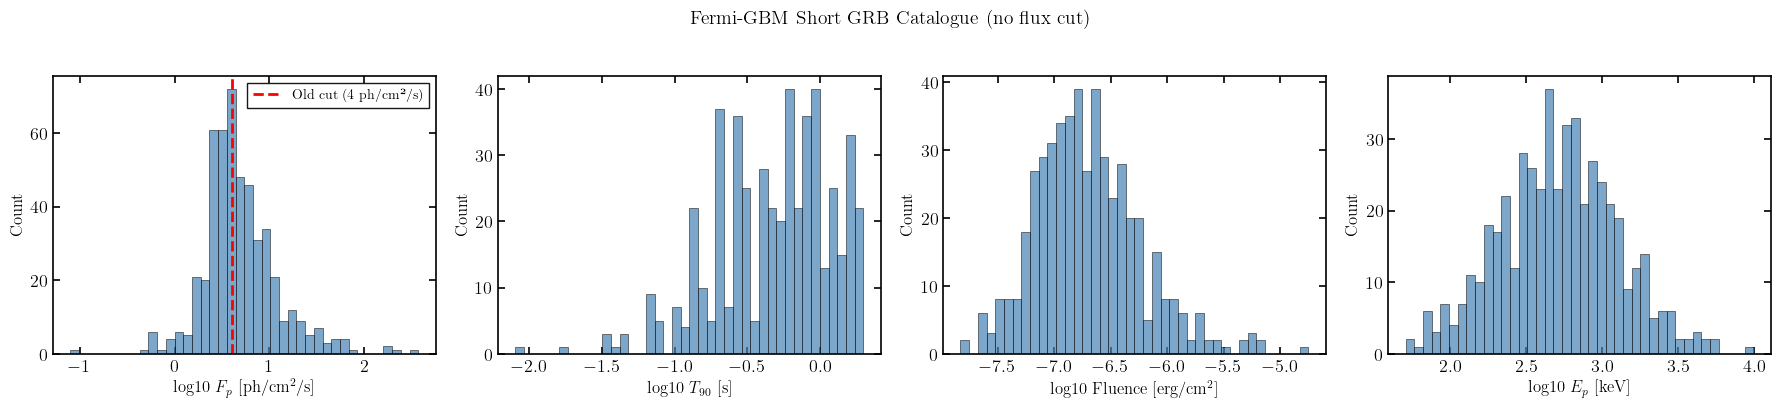

In [88]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, data, label in zip(axes, 
    [pflux_nocut, t90_nocut, fluence_nocut, epeak_nocut],
    [r'$F_p$ [ph/cm$^2$/s]', r'$T_{90}$ [s]', r'Fluence [erg/cm$^2$]', r'$E_p$ [keV]']):
    hist_data = data[data > 0]  # Filter out non-positive values for log10
    # where is the data > 0? This is important for log10, as log10(0) is undefined and log10 of negative numbers is not real.
    print(f"{label}: {len(data)} total, {len(hist_data)} with data > 0")
    ax.hist(np.log10(hist_data), bins=40, color='steelblue', alpha=0.7, edgecolor='k', lw=0.5)
    ax.set_xlabel(f'log10 {label}', fontsize=12)
    ax.set_ylabel('Count', fontsize=12)

axes[0].axvline(np.log10(4), color='red', ls='--', lw=2, label='Old cut (4 ph/cm²/s)')
axes[0].legend(fontsize=10)

plt.suptitle('Fermi-GBM Short GRB Catalogue (no flux cut)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Sigmoid Detection Efficiency Model

Instead of a hard cut $F_p > F_{\rm LIM}$, each simulated GRB with peak flux $F_p$ is
**detected** with probability:

$$
\eta(F_p) = \frac{1}{1 + \exp\!\left(-\frac{F_p - F_{\rm th}}{\sigma_F}\right)}
$$

- When $F_p \gg F_{\rm th}$: $\eta \to 1$ (always detected)
- When $F_p \ll F_{\rm th}$: $\eta \to 0$ (never detected)
- At $F_p = F_{\rm th}$: $\eta = 0.5$ (50% detection chance)

The width $\sigma_F$ controls how sharp the transition is:
- Small $\sigma_F$ → approaches a hard step function
- Large $\sigma_F$ → gradual transition over a wide flux range

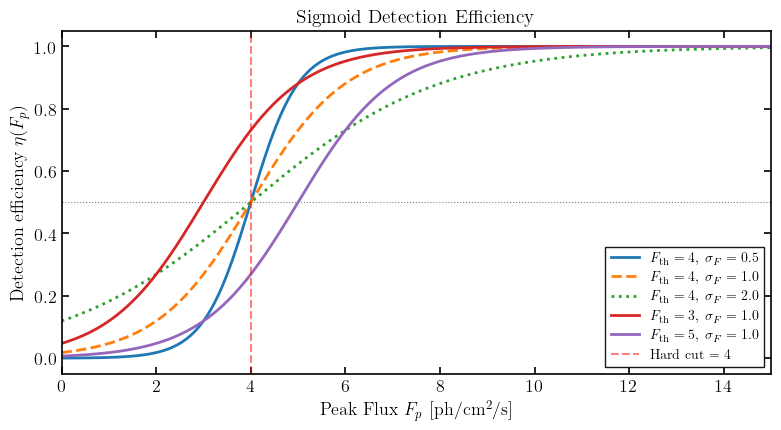

In [89]:
def sigmoid_efficiency(Fp, F_th, sigma_F):
    """
    Sigmoid (logistic) detection efficiency.
    
    Parameters
    ----------
    Fp : array-like
        Peak flux values [ph/cm^2/s].
    F_th : float
        Flux threshold (sigmoid midpoint) [ph/cm^2/s].
    sigma_F : float
        Sigmoid width [ph/cm^2/s]. Must be > 0.
    
    Returns
    -------
    eta : array
        Detection probability in [0, 1].
    """
    x = (np.asarray(Fp) - F_th) / sigma_F
    # Clip for numerical stability
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))


# ── Visualize the sigmoid for several (F_th, sigma_F) pairs ──────────────────
Fp_grid = np.linspace(0, 15, 500)

fig, ax = plt.subplots(figsize=(8, 4.5))
for F_th, sF, ls in [(4, 0.5, '-'), (4, 1.0, '--'), (4, 2.0, ':'),
                       (3, 1.0, '-'), (5, 1.0, '-')]:
    eta = sigmoid_efficiency(Fp_grid, F_th, sF)
    ax.plot(Fp_grid, eta, ls=ls, lw=2,
            label=rf'$F_{{\rm th}}={F_th},\; \sigma_F={sF}$')

ax.axhline(0.5, color='grey', ls=':', lw=0.8)
ax.axvline(4, color='red', ls='--', lw=1.5, alpha=0.5, label='Hard cut = 4')
ax.set_xlabel(r'Peak Flux $F_p$ [ph/cm$^2$/s]', fontsize=13)
ax.set_ylabel(r'Detection efficiency $\eta(F_p)$', fontsize=13)
ax.set_title('Sigmoid Detection Efficiency', fontsize=14)
ax.legend(fontsize=10, loc='lower right')
ax.set_xlim(0, 15)
ax.set_ylim(-0.05, 1.05)
plt.tight_layout()
plt.show()

## 7. Modified Monte Carlo with Sigmoid Detection

The key change is in `make_observations_sigmoid`: instead of a hard flux cut,
each GRB is kept with probability $\eta(F_p)$. This means faint GRBs near
the threshold have a non-zero chance of being detected, matching the real
behaviour of Fermi-GBM more closely.

### Parameter vector

$$
\boldsymbol{\theta} = [k,\, \log L_0,\, \log\mu_E,\, \sigma_E,\, \log\mu_\tau,\, \sigma_\tau,\, f_j,\, F_{\rm th},\, \sigma_F]
$$

In [90]:
# ══════════════════════════════════════════════════════════════════════════════
# Modified Monte Carlo: sigmoid detection efficiency
# ══════════════════════════════════════════════════════════════════════════════

# Pre-filter threshold: discard GRBs with eta(Fp) < ETA_MIN before the
# expensive time-evolution computation.  Solving eta = ETA_MIN for Fp gives:
#   Fp_min = F_th + sigma_F * ln(ETA_MIN / (1 - ETA_MIN))
# For ETA_MIN = 0.05 this is F_th - 2.944 * sigma_F.
ETA_MIN = 0.15 #15% detection chance minimum to avoid simulating EXTREMLY faint events
_LOG_ODDS_MIN = np.log(ETA_MIN / (1.0 - ETA_MIN))   # ≈ -2.944

def make_observations_sigmoid(
    thetas,
    params: SimParams,
    interps: Interps,
    limits: dict = DEFAULT_LIMITS,
    n_events: int = N_SIMS,
):
    """
    Generate synthetic GRB observations with sigmoid detection efficiency.

    Instead of a hard flux cut, each GRB is detected with probability:
        eta(Fp) = 1 / (1 + exp(-(Fp - F_th) / sigma_F))

    A cheap pre-filter removes GRBs whose *approximate* peak flux (F_p_real)
    gives eta < 5%, avoiding the expensive time-evolution for hopelessly
    faint events.

    Parameters
    ----------
    thetas : list (9 elements)
        [k, L_L0, L_mu_E, sigma_E, L_mu_tau, sigma_tau, fj, F_th, sigma_F]
    params : SimParams
    interps : Interps
    limits : dict
        Only T90_LIM and EP_LIM_* are used (F_LIM is replaced by sigmoid).
    n_events : int

    Returns
    -------
    dict or None
    """
    F_th    = thetas[7]
    sigma_F = thetas[8]

    # Generate macro properties (uses only the first 7 elements internally;
    # the 7th element is fj which is not used in generate_macro_properties)
    m_prop = generate_macro_properties(thetas[:7], params, interps, n_events)

    if len(m_prop["t_peak_c_z"]) == 0:
        return None

    # ── Pre-filter 1: T90 (cheap, performance only) ──────────────────────────
    # since T90 > tpeak if tpeak is already too large don't include it
    prefilter_mask = m_prop['t_peak_c_z'] < limits["T90_LIM"]

    # ── Pre-filter 2: flux sigmoid floor ─────────────────────────────────────
    # F_p_real is a fast analytic estimate.  If eta(F_p_real) < ETA_MIN the
    # GRB is almost certainly undetectable, so skip it before the expensive
    # time-evolution and sliding-window peak-flux computation.
    Fp_floor = F_th + sigma_F * _LOG_ODDS_MIN   # flux where eta = ETA_MIN
    prefilter_mask &= m_prop['F_p_real'] > Fp_floor

    if np.sum(prefilter_mask) <= 5:
        return None

    m_prop_pre = {k: v[prefilter_mask] for k, v in m_prop.items()}

    # ── Compute detailed observables ─────────────────────────────────────────
    P_F_64ms_50_300      = compute_Fp_64_ms_optimized(m_prop_pre, interps)
    t_90_array, f_det_in = compute_time_evolution(m_prop_pre, interps)

    # ── T90 cut (physical) ───────────────────────────────────────────────────
    t90_mask = t_90_array < limits["T90_LIM"]

    # ── Sigmoid detection: probabilistic flux selection ───────────────────────
    eta = sigmoid_efficiency(P_F_64ms_50_300, F_th, sigma_F)
    rng = params.rng
    detect_draw = rng.uniform(0, 1, size=len(eta))
    flux_detected = detect_draw < eta

    detection_mask = t90_mask & flux_detected
    triggered_events = int(np.sum(detection_mask))

    if triggered_events == 0:
        return None

    # ── Ep quality cut ────────────────────────────────────────────────────────
    shape_mask = (
        (m_prop_pre["E_p_obs"] > limits["EP_LIM_LOWER"]) &
        (m_prop_pre["E_p_obs"] < limits["EP_LIM_UPPER"])
    )
    final_mask = detection_mask & shape_mask

    if np.sum(final_mask) == 0:
        return None

    return {
        "t_det"                : t_90_array[final_mask],
        "f_det"                : f_det_in[final_mask],
        "Ep_det"               : m_prop_pre["E_p_obs"][final_mask],
        "Fp_det"               : P_F_64ms_50_300[final_mask],
        "z_det"                : m_prop_pre["z"][final_mask],
        "theta_v_det"          : m_prop_pre["theta_v"][final_mask],
        "R_F_theta_det"        : m_prop_pre["R_F_theta"][final_mask],
        "triggered_events"     : triggered_events,
        "isotropic_energy_det" : m_prop_pre["isotropic_energy"][final_mask],
    }

print("make_observations_sigmoid defined ✓")

make_observations_sigmoid defined ✓


## 8. Score Function and Likelihood

We reuse the CvM-based shape scoring and Poisson rate term.
The likelihood structure is identical to `log_likelihood_fj`, but calls
`make_observations_sigmoid` and unpacks the two extra parameters.

In [91]:
def _local_rng_from_thetas(thetas):
    """Reproducible local RNG seeded from a hash of the parameter vector."""
    arr = np.array(thetas, dtype=np.float64)
    seed_int = int(abs(hash(arr.tobytes()))) % (2**31)
    return np.random.default_rng(seed_int)

def score_func(y_sim, y_obs, rng=None):
    """CvM two-sample score on log10-transformed observables."""
    _rng = np.random.default_rng() if rng is None else rng
    y_resample = cdf_sample(y_sim, len(y_obs), rng=_rng)
    y_in  = np.log10(y_resample)
    y_out = np.log10(y_obs)
    stat  = cramervonmises_2samp(y_in, y_out)
    return np.log(max(stat.pvalue, 1e-300))

def log_likelihood_sigmoid(
    thetas,
    params: SimParams,
    interps: Interps,
    limits: dict = DEFAULT_LIMITS,
):
    """
    Log-likelihood with sigmoid detection efficiency.

    Parameters
    ----------
    thetas : list (9 elements)
        [k, L_L0, L_mu_E, sigma_E, L_mu_tau, sigma_tau, fj, F_th, sigma_F]

    Returns
    -------
    tuple : (logL, yearly_rate_sim, logL_epeak, logL_t90, logL_pflux, logL_fluence)
    """
    fj      = thetas[6]
    n_years = params.triggered_years

    geo_efficiency = 1.0 - np.cos(params.theta_v_max)
    bns_per_year   = len(params.z_arr)

    n_events = int(bns_per_year * n_years * geo_efficiency)

    if n_events < 50:
        return -np.inf, None, None, None, None, None

    obs = make_observations_sigmoid(
        thetas, params, interps, limits=limits, n_events=n_events
    )

    if obs is None or len(obs["t_det"]) < 10:
        return -np.inf, None, None, None, None, None

    # Shape scores
    local_rng = _local_rng_from_thetas(thetas)

    logL_shape_t90     = score_func(obs["t_det"],  params.duration_data, rng=local_rng)
    logL_shape_epeak   = score_func(obs["Ep_det"], params.epeak_data,    rng=local_rng)
    logL_shape_pflux   = score_func(obs["Fp_det"], params.pflux_data,    rng=local_rng)
    logL_shape_fluence = score_func(obs["f_det"],  params.fluence_data,  rng=local_rng)
    total_logL_shape   = (
        logL_shape_epeak + logL_shape_t90
        + logL_shape_pflux + logL_shape_fluence
    )

    # Poisson rate term
    total_observed   = params.yearly_rate * n_years
    triggered_events = obs["triggered_events"]
    expected_total   = triggered_events * fj * GBM_EFF

    if expected_total <= 0:
        return -np.inf, None, None, None, None, None

    logL_rate             = poiss_log(k=total_observed, mu=expected_total)
    simulated_yearly_rate = expected_total / n_years

    return (
        total_logL_shape + logL_rate,
        simulated_yearly_rate,
        logL_shape_epeak,
        logL_shape_t90,
        logL_shape_pflux,
        logL_shape_fluence,
    )

print("log_likelihood_sigmoid defined ✓")

log_likelihood_sigmoid defined ✓


## 9. Prior (9 parameters)

We define a flat prior for all 9 parameters:

| # | Parameter | Symbol | Prior Range | Description |
|---|-----------|--------|-------------|-------------|
| 0 | `k` | $k$ | $[1.5, 12]$ | Luminosity function power-law index |
| 1 | `L_L0` | $\log L_0$ | $[-3, 2]$ | Energy scale |
| 2 | `L_mu_E` | $\log\mu_E$ | $[2.5, 4]$ | Mean peak energy |
| 3 | `sigma_E` | $\sigma_E$ | $[0, 1]$ | Peak energy scatter |
| 4 | `L_mu_tau` | $\log\mu_\tau$ | $[-2, 0.3]$ | Mean peak time |
| 5 | `sigma_tau` | $\sigma_\tau$ | $[0, 1.8]$ | Peak time scatter |
| 6 | `f_j` | $f_j$ | $[0, 20]$ | Jet fraction |
| 7 | `F_th` | $F_{\rm th}$ | $[0.5, 10]$ | Sigmoid flux threshold |
| 8 | `sigma_F` | $\sigma_F$ | $[0.01, 5]$ | Sigmoid width |

In [92]:
PRIOR_BOUNDS_SIGMOID = {
    'k'        : (1.5, 12),
    'L_L0'     : (-3, 2),
    'L_mu_E'   : (2.5, 4),
    'sigma_E'  : (0, 1),
    'L_mu_tau' : (-2, np.log10(2)),   # max peak time ≈ 2s
    'sigma_tau': (0, 1.8),
    'f_j'      : (0, 20),
    'F_th'     : (0.5, 10),           # sigmoid midpoint [ph/cm^2/s]
    'sigma_F'  : (0.01, 5),           # sigmoid width [ph/cm^2/s]
}


def log_prior_sigmoid(thetas):
    """Flat prior for the 9-parameter sigmoid detection model."""
    names = ['k', 'L_L0', 'L_mu_E', 'sigma_E', 'L_mu_tau', 'sigma_tau',
             'f_j', 'F_th', 'sigma_F']
    for val, name in zip(thetas, names):
        lo, hi = PRIOR_BOUNDS_SIGMOID[name]
        if not (lo < val < hi):
            return -inf
    return 0.0


# Quick test
test_theta_9 = [2.5, -0.5, 3.2, 0.35, -0.3, 0.7, 0.15, 4.0, 1.0]
print(f"Prior at test point: {log_prior_sigmoid(test_theta_9)}")
print(f"Prior outside bounds: {log_prior_sigmoid([2.5, -0.5, 3.2, 0.35, -0.3, 0.7, 0.15, 4.0, 10])}")

Prior at test point: 0.0
Prior outside bounds: -inf


## 10. Log-Probability and Sanity Check

In [93]:
# ── Modified limits: set F_LIM to 0 so the hard cut doesn't interfere ────────
# The sigmoid handles all flux-based selection.
LIMITS_SIGMOID = dict(DEFAULT_LIMITS)
LIMITS_SIGMOID["F_LIM"] = 0.0  # disabled — sigmoid handles this


def log_probability(thetas):
    lp = log_prior_sigmoid(thetas)
    if not np.isfinite(lp):
        return -inf, None, None, None, None, None
    ll, yr_rate, lE, lT, lP, lF = log_likelihood_sigmoid(
        thetas,
        sim_params,
        interps,
        limits=LIMITS_SIGMOID,
    )
    return lp + ll, yr_rate, lE, lT, lP, lF


# ── Sanity check ─────────────────────────────────────────────────────────────
geo_eff        = 1 - np.cos(sim_params.theta_v_max)
n_years        = sim_params.triggered_years
n_events_check = int(len(sim_params.z_arr) * n_years * geo_eff)

print(f"Geometric MC draw size : {n_events_check:,} events")
print(f"  = {len(sim_params.z_arr):,} BNS/yr × {n_years:.1f} yr × {geo_eff:.4f}")

thetas_test = [2.5, -0.5, 3.2, 0.35, -0.3, 0.7, 0.15, 4.0, 1.0]
result = log_probability(thetas_test)
print(f"\nlog_prob at test point : {result[0]:.3f}")
print(f"simulated yearly rate  : {result[1]}")

Geometric MC draw size : 95,788 events
  = 359,079 BNS/yr × 17.6 yr × 0.0152

log_prob at test point : -532.769
simulated yearly rate  : 9.917972724488934


## 11. Walker Initialisation

In [94]:
N_WALKERS = 20       # ≥ 2 × N_DIM = 18
N_STEPS   = 1000
N_DIM     = 9

rng_init = np.random.default_rng(42)

# Standard 7 parameters (same initialisation as structured_jet_run)
k_init        = rng_init.uniform(2, 4, N_WALKERS)
L_L0_init     = rng_init.uniform(-1.5, 0, N_WALKERS)
L_mu_E_init   = rng_init.uniform(3, 3.5, N_WALKERS)
sigma_E_init  = rng_init.uniform(0.2, 0.4, N_WALKERS)
L_mu_tau_init = rng_init.uniform(-1, 0, N_WALKERS)
sigma_tau_init= rng_init.uniform(0.5, 1, N_WALKERS)
fj_init       = rng_init.uniform(0.05, 0.8, N_WALKERS)

# New sigmoid parameters — initialised near sensible values
F_th_init     = rng_init.uniform(2, 6, N_WALKERS)     # near the old hard cut of 4
sigma_F_init  = rng_init.uniform(0.3, 2.0, N_WALKERS) # moderate width

initial_pos = np.column_stack([
    k_init, L_L0_init, L_mu_E_init, sigma_E_init,
    L_mu_tau_init, sigma_tau_init, fj_init,
    F_th_init, sigma_F_init,
])

print(f"Walkers: {initial_pos.shape}")
print(f"F_th range:    [{F_th_init.min():.2f}, {F_th_init.max():.2f}]")
print(f"sigma_F range: [{sigma_F_init.min():.2f}, {sigma_F_init.max():.2f}]")

Walkers: (20, 9)
F_th range:    [2.09, 5.75]
sigma_F range: [0.36, 1.99]


## 12. MCMC Run

Blobs store per-step diagnostics: `(yearly_rate, logL_epeak, logL_t90, logL_pflux, logL_fluence)`.

In [118]:
backend_file = output_dir / "emcee_sigmoid.h5"

blobs_dtype = [
    ("yearly_rate",  float),
    ("logL_epeak",   float),
    ("logL_t90",     float),
    ("logL_pflux",   float),
    ("logL_fluence", float),
]

backend = emcee.backends.HDFBackend(str(backend_file))

# Set PARALLEL = False if you encounter pickling errors (macOS) or want to debug
PARALLEL = True

run_mcmc_parallel(
    log_probability=log_probability,   
    initial_pos=initial_pos,
    max_n=N_STEPS*60,
    backend=backend,
    parallel=PARALLEL,
    blobs_dtype=blobs_dtype,
    progress=True,
)

print(f"\nChain saved to {backend_file}")

Resuming from iteration 40000/60000
Running MCMC with 11 workers (20000 steps)...


100%|██████████| 20000/20000 [53:20<00:00,  6.25it/s]  


Resuming from iteration 40000/60000
Running MCMC with 11 workers (20000 steps)...


100%|██████████| 20000/20000 [53:20<00:00,  6.25it/s]  


✓ MCMC complete (parallel). Mean acceptance: 0.022

Chain saved to Output_files/tutorial5_sigmoid_detection__2026-03-04_14-14-06/emcee_sigmoid.h5


## 13. Convergence Diagnostics

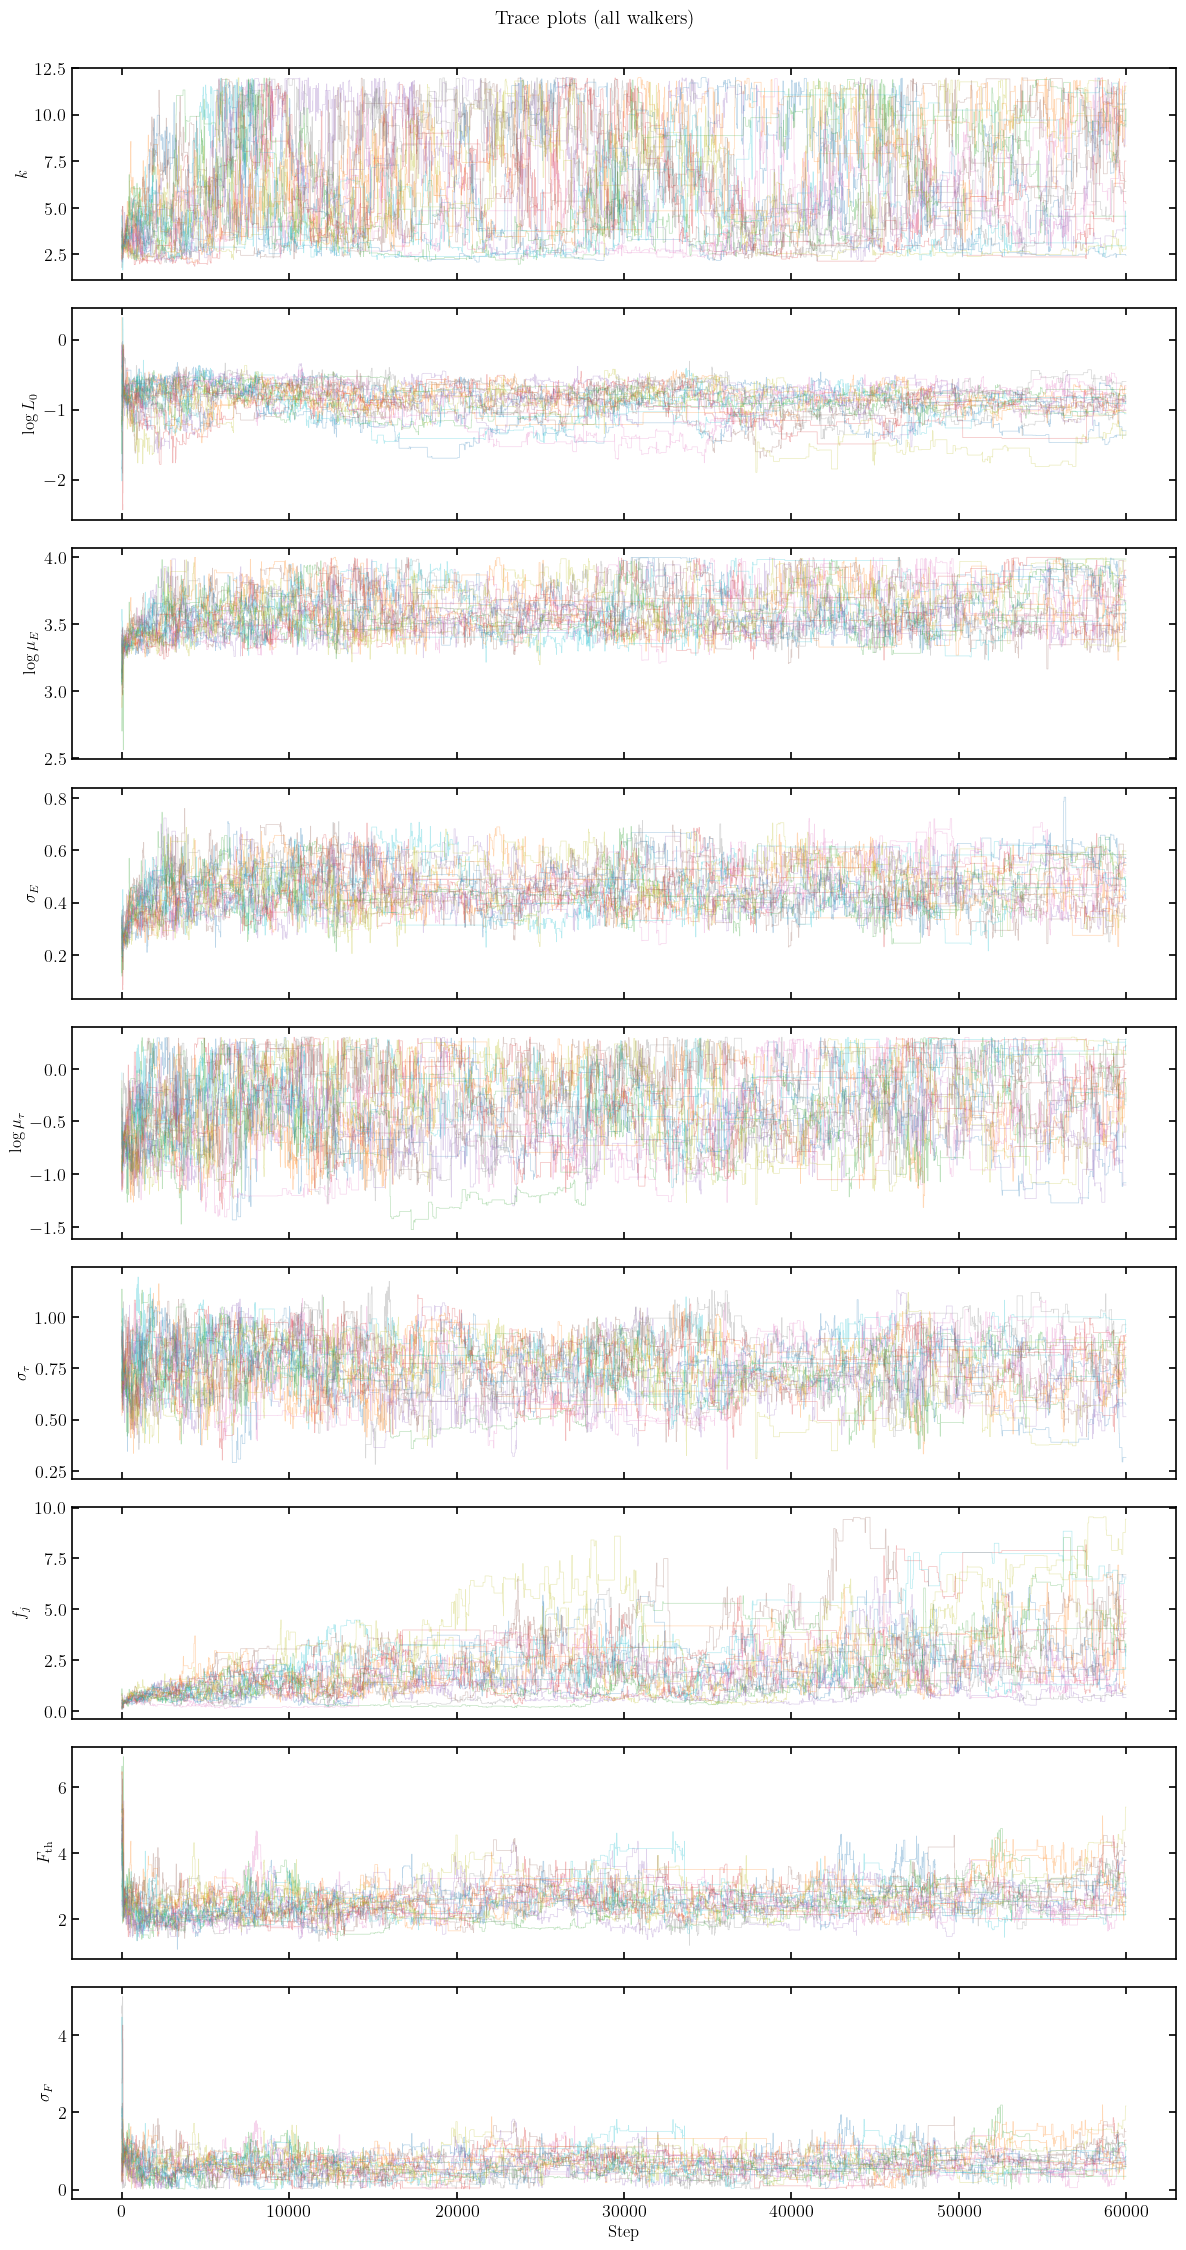

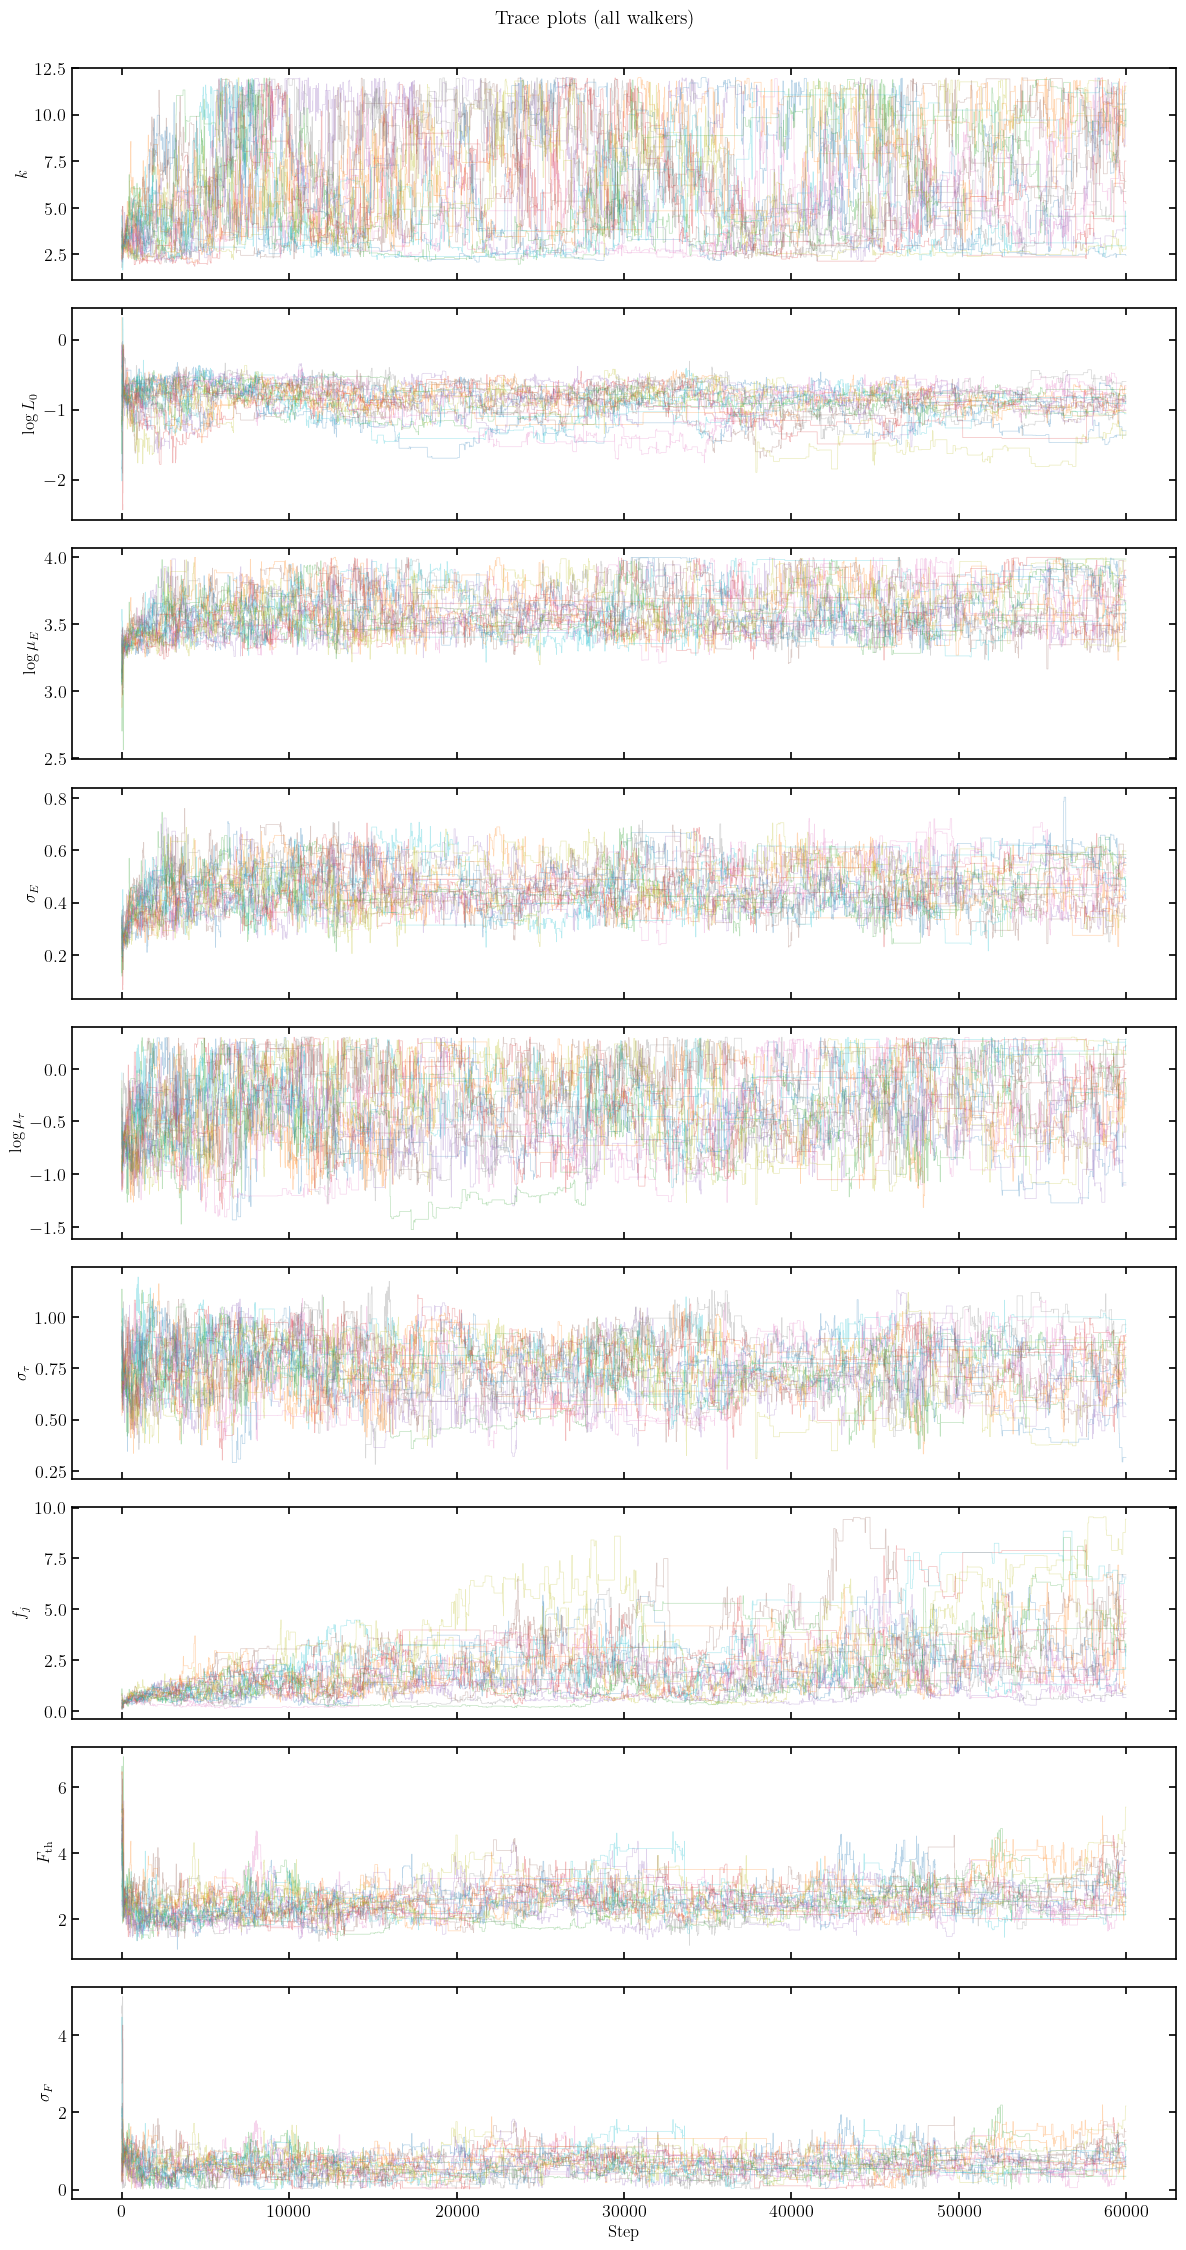

Autocorrelation times:
  $k$                 : 4309.8
  $\log L_0$          : 3739.1
  $\log\mu_E$         : 2766.3
  $\sigma_E$          : 2436.3
  $\log\mu_\tau$      : 2921.4
  $\sigma_\tau$       : 2865.6
  $f_j$               : 5149.1
  $F_{\rm th}$        : 3705.9
  $\sigma_F$          : 2741.8

Suggested DISCARD=10298, THIN=1218


In [119]:
reader = emcee.backends.HDFBackend(str(backend_file), read_only=True)
chain  = reader.get_chain()  # (steps, walkers, ndim)

labels_9 = [
    r'$k$', r'$\log L_0$', r'$\log\mu_E$', r'$\sigma_E$',
    r'$\log\mu_\tau$', r'$\sigma_\tau$', r'$f_j$',
    r'$F_{\rm th}$', r'$\sigma_F$',
]

fig, axes = plt.subplots(N_DIM, 1, figsize=(12, 2.5 * N_DIM), sharex=True)
for i, (ax, label) in enumerate(zip(axes, labels_9)):
    ax.plot(chain[:, :, i], alpha=0.3, lw=0.5)
    ax.set_ylabel(label, fontsize=12)
axes[-1].set_xlabel('Step', fontsize=12)
plt.suptitle('Trace plots (all walkers)', fontsize=14, y=1.0)
plt.tight_layout()
plt.show()

# ── Autocorrelation ──────────────────────────────────────────────────────────
try:
    tau = reader.get_autocorr_time(tol=0)
    print("Autocorrelation times:")
    for name, t in zip(labels_9, tau):
        print(f"  {name:20s}: {t:.1f}")
    DISCARD = int(2 * max(tau))
    THIN    = max(1, int(0.5 * min(tau)))
    print(f"\nSuggested DISCARD={DISCARD}, THIN={THIN}")
except Exception as e:
    print(f"Autocorrelation estimation failed: {e}")
    DISCARD = min(500, chain.shape[0] // 3)
    THIN    = 1
    print(f"Using fallback DISCARD={DISCARD}, THIN={THIN}")

## 14. Corner Plot

Flat samples: (800, 9)


Flat samples: (800, 9)


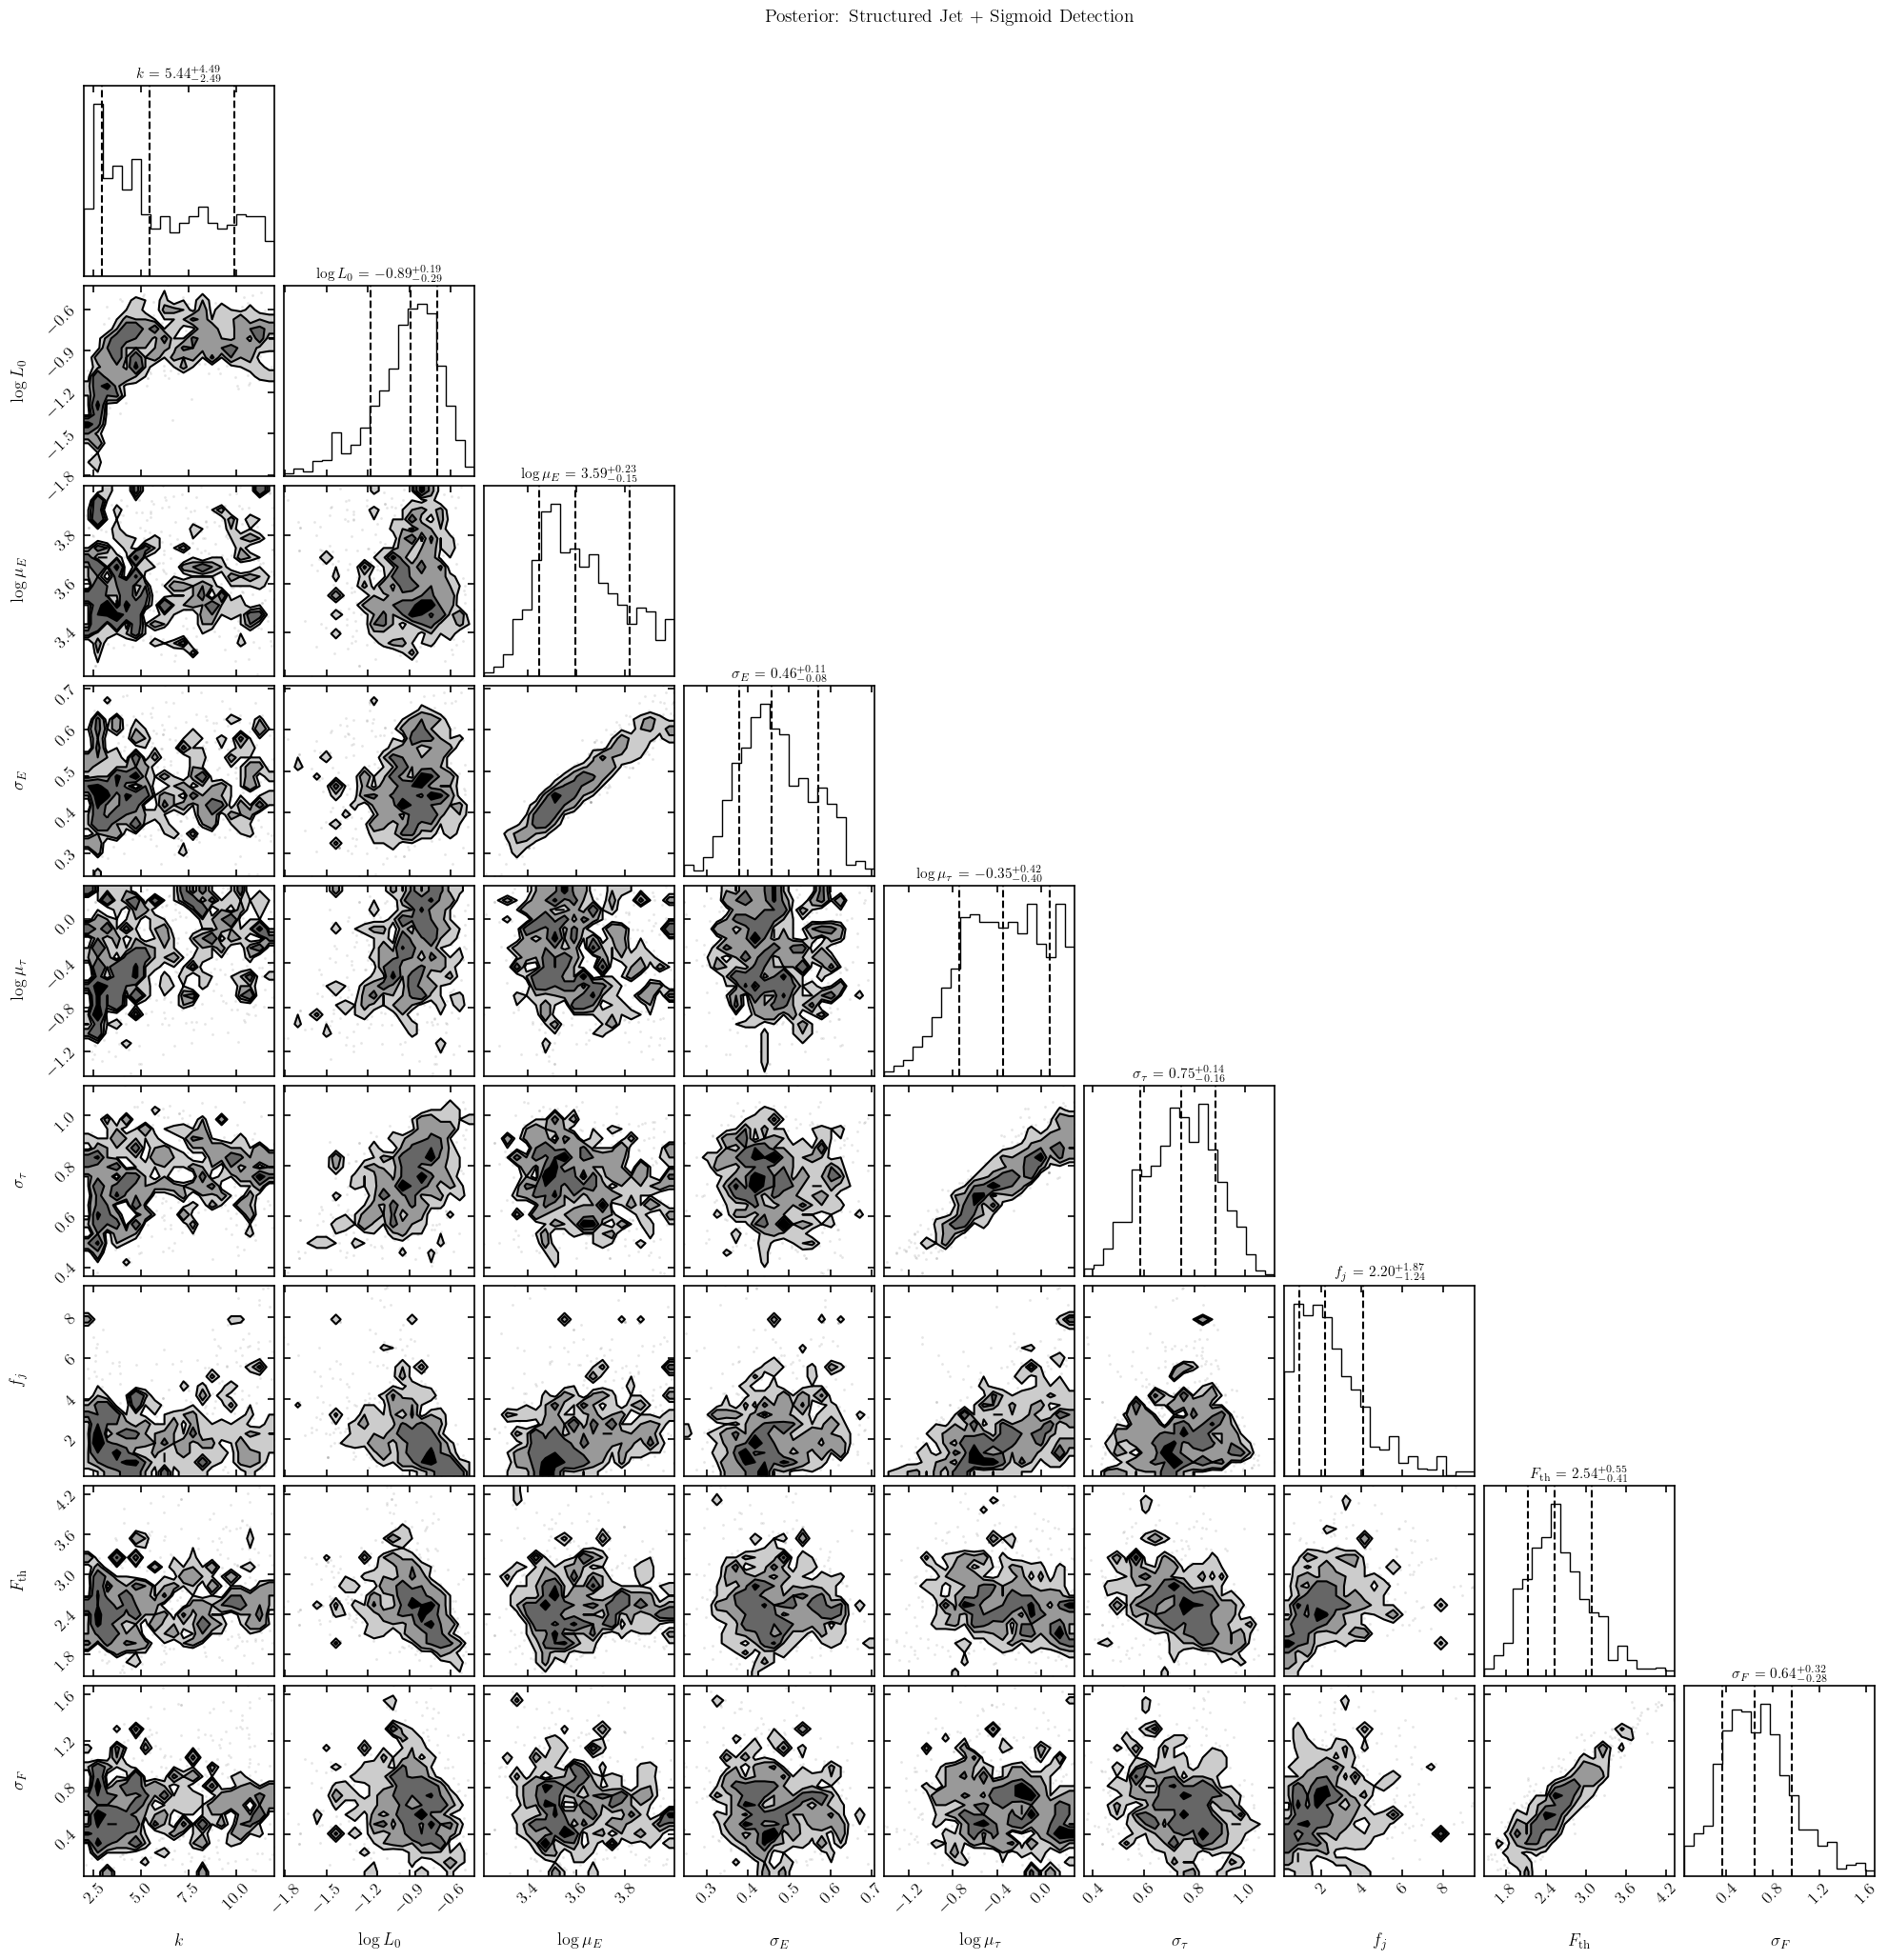

In [120]:
import corner

flat_samples = reader.get_chain(discard=DISCARD, thin=THIN, flat=True)
print(f"Flat samples: {flat_samples.shape}")

fig = corner.corner(
    flat_samples,
    labels=labels_9,
    quantiles=[0.16, 0.5, 0.84],
    show_titles=True,
    title_kwargs={"fontsize": 11},
    fill_contours=True,
)
plt.suptitle('Posterior: Structured Jet + Sigmoid Detection', y=1.02, fontsize=14)
fig.savefig(output_dir / 'corner_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()

## 15. Sigmoid Posterior Visualization

Draw sigmoid curves from the posterior to see the inferred detection efficiency.

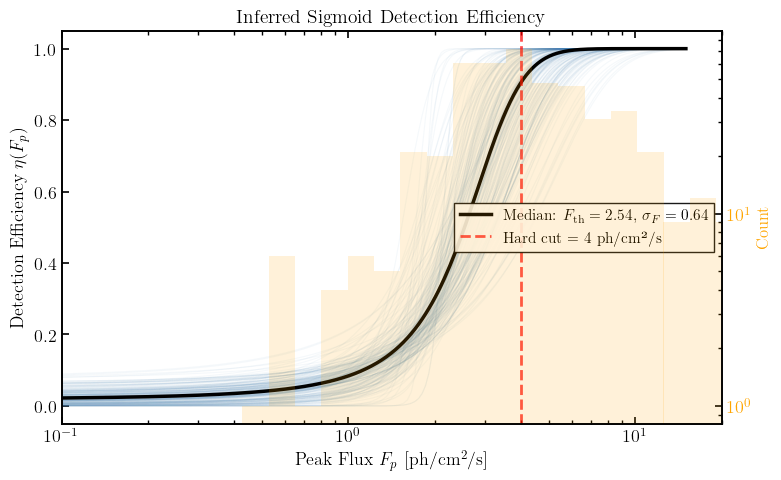


=== Detection efficiency parameters ===
  $k$                 : 5.438  (+4.488 / -2.493)
  $\log L_0$          : -0.893  (+0.193 / -0.289)
  $\log\mu_E$         : 3.593  (+0.225 / -0.146)
  $\sigma_E$          : 0.458  (+0.112 / -0.079)
  $\log\mu_\tau$      : -0.349  (+0.425 / -0.395)
  $\sigma_\tau$       : 0.747  (+0.139 / -0.159)
  $f_j$               : 2.203  (+1.871 / -1.240)
  $F_{\rm th}$        : 2.539  (+0.549 / -0.410)
  $\sigma_F$          : 0.644  (+0.320 / -0.279)


In [121]:
Fp_grid = np.linspace(0, 15, 300)

fig, ax = plt.subplots(figsize=(8, 5))

# Draw 200 random posterior samples
n_draw = min(200, len(flat_samples))
idx_draw = np.random.choice(len(flat_samples), n_draw, replace=False)

for i in idx_draw:
    F_th_i    = flat_samples[i, 7]
    sigma_F_i = flat_samples[i, 8]
    eta_i = sigmoid_efficiency(Fp_grid, F_th_i, sigma_F_i)
    ax.plot(Fp_grid, eta_i, color='steelblue', alpha=0.05, lw=0.8)

# Median sigmoid
F_th_med    = np.median(flat_samples[:, 7])
sigma_F_med = np.median(flat_samples[:, 8])
eta_med = sigmoid_efficiency(Fp_grid, F_th_med, sigma_F_med)
ax.plot(Fp_grid, eta_med, 'k-', lw=2.5, label=f'Median: $F_{{\\rm th}}={F_th_med:.2f}$, $\\sigma_F={sigma_F_med:.2f}$')

# Old hard cut
ax.axvline(4, color='red', ls='--', lw=2, alpha=0.7, label='Hard cut = 4 ph/cm²/s')

# Observed flux histogram (normalized to max=1 for overlay)
hist_vals, bin_edges = np.histogram(np.log10(pflux_nocut[pflux_nocut>0]), bins=40)
bin_centers = 10**((bin_edges[:-1] + bin_edges[1:]) / 2)
ax2 = ax.twinx()
ax2.bar(bin_centers, hist_vals, width=np.diff(10**bin_edges), alpha=0.15, color='orange', label='Data')
ax2.set_ylabel('Count', fontsize=12, color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.set_yscale('log')
ax.set_xlabel(r'Peak Flux $F_p$ [ph/cm$^2$/s]', fontsize=13)
ax.set_ylabel(r'Detection Efficiency $\eta(F_p)$', fontsize=13)
ax.set_title('Inferred Sigmoid Detection Efficiency', fontsize=14)
ax.legend(fontsize=11, loc='center right')
ax.set_xlim(1e-1, 20)
ax.set_ylim(-0.05, 1.05)
ax.set_xscale('log')
plt.tight_layout()
fig.savefig(output_dir / 'sigmoid_posterior.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary
print("\n=== Detection efficiency parameters ===")
for i, name in enumerate(labels_9):
    q16, q50, q84 = np.percentile(flat_samples[:, i], [16, 50, 84])
    print(f"  {name:20s}: {q50:.3f}  (+{q84-q50:.3f} / -{q50-q16:.3f})")

## 16. Posterior Predictive Check (CDFs)

Draw a sample from the posterior and compare the simulated vs. observed CDFs.

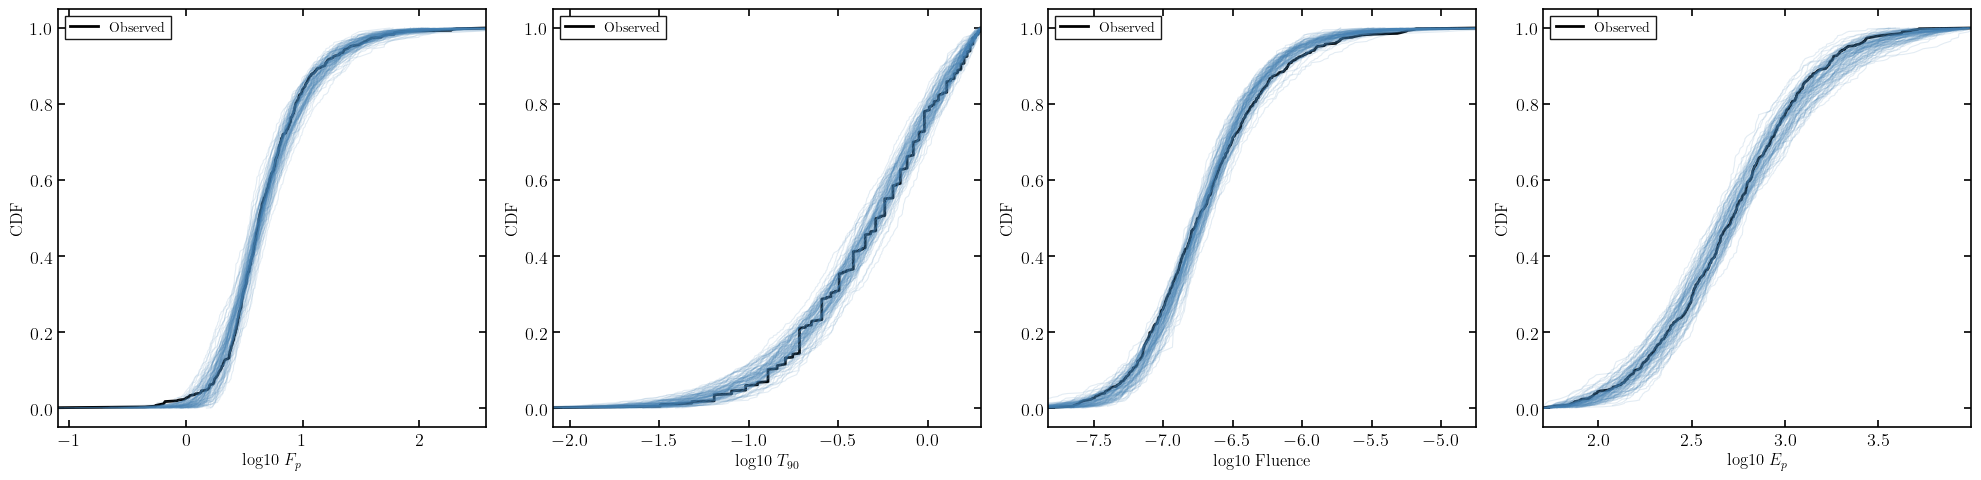

In [122]:
# Pick a few posterior samples and generate PPC
n_ppc = 100
idx_ppc = np.random.choice(len(flat_samples), n_ppc, replace=False)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
obs_labels = [r'$F_p$', r'$T_{90}$', r'Fluence', r'$E_p$']
obs_keys   = ['Fp_det', 't_det', 'f_det', 'Ep_det']
obs_data   = [pflux_nocut, t90_nocut, fluence_nocut, epeak_nocut]

for ax, key, data_obs, label in zip(axes, obs_keys, obs_data, obs_labels):
    # Observed CDF
    x_obs = np.sort(np.log10(data_obs[data_obs>0]))
    cdf_obs = np.arange(1, len(x_obs) + 1) / len(x_obs)
    ax.plot(x_obs, cdf_obs, 'k-', lw=2, label='Observed')

    # Simulated CDFs
    for i in idx_ppc:
        theta_i = flat_samples[i]
        geo_eff = 1 - np.cos(sim_params.theta_v_max)
        n_ev = int(len(sim_params.z_arr) * sim_params.triggered_years * geo_eff)
        obs_i = make_observations_sigmoid(
            theta_i, sim_params, interps,
            limits=LIMITS_SIGMOID, n_events=n_ev,
        )
        if obs_i is not None and len(obs_i[key]) > 5:
            x_sim = np.sort(np.log10(obs_i[key]))
            cdf_sim = np.arange(1, len(x_sim) + 1) / len(x_sim)
            ax.plot(x_sim, cdf_sim, color='steelblue', alpha=0.15, lw=0.8)

    ax.set_xlim(x_obs.min(), x_obs.max())
    ax.set_xlabel(f'log10 {label}', fontsize=12)
    ax.set_ylabel('CDF', fontsize=12)
    ax.legend(fontsize=10)

plt.tight_layout()
fig.savefig(output_dir / 'ppc_sigmoid.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Summary

This notebook:

1. **Removed the hard peak-flux cut** from the Fermi-GBM catalogue, keeping only $E_p$ quality cuts
2. **Replaced** the hard detection threshold with a **sigmoid (logistic) efficiency** $\eta(F_p; F_{\rm th}, \sigma_F)$
3. **Added two free parameters** ($F_{\rm th}$, $\sigma_F$) to the MCMC, for a total of **9 parameters**
4. The MCMC constrains both the GRB population parameters and the shape of the detection efficiency

### Physical interpretation

- **$F_{\rm th}$** represents the effective 50% detection threshold
- **$\sigma_F$** measures how sharp the transition is — small $\sigma_F$ recovers a near-step function
- If the posterior favours $F_{\rm th} \approx 4$ and small $\sigma_F$, the data are consistent with a hard cut
- If $\sigma_F$ is large, there is evidence for a gradual detection efficiency roll-off